In [2]:
import sys
sys.path.append("..")

import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import MODEL_DIR, LABEL_MAP
from src.dataset import load_annotations, create_tf_dataset

In [3]:
test_df = load_annotations("annotations_test.json")
test_ds = create_tf_dataset(test_df, is_training=False)

model = tf.keras.models.load_model(MODEL_DIR / "best_mobilenet.keras")

In [4]:
y_true = test_df["label_id"].values
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 384ms/step


In [5]:
target_names = list(LABEL_MAP.keys())
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

       alert       0.95      0.94      0.94      1728
  microsleep       0.77      0.85      0.81       416
     yawning       0.98      0.94      0.96       358

    accuracy                           0.92      2502
   macro avg       0.90      0.91      0.90      2502
weighted avg       0.93      0.92      0.92      2502



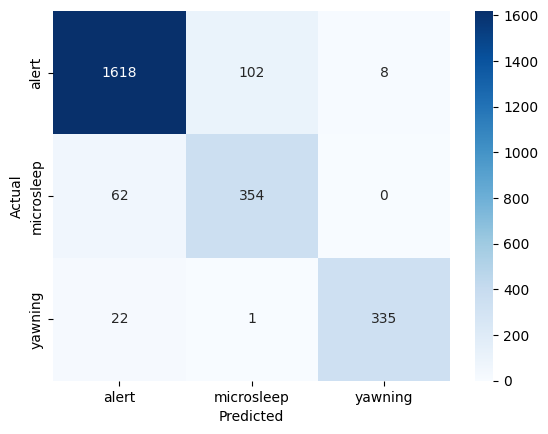

In [6]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()